# Лабораторная 3 — Разметка и аугментация (Racoon detection)

In [ ]:
from pathlib import Path
import json
import shutil
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import albumentations as A
from sklearn.model_selection import train_test_split

BASE_DIR = Path('.')
IMG_DIR = BASE_DIR / 'Racoon Images' / 'images'
LABELS_PATH = BASE_DIR / 'train_labels_.csv'
OUTPUT_DIR = BASE_DIR / 'prepared_raccoon'
AUG_DIR = BASE_DIR / 'prepared_raccoon_aug'

df = pd.read_csv(LABELS_PATH)
df.head()

,filename,width,height,class,xmin,ymin,xmax,ymax
0,raccoon-17.jpg,259,194,raccoon,95,60,167,118
1,raccoon-11.jpg,660,432,raccoon,3,1,461,431
2,raccoon-63.jpg,600,400,raccoon,74,107,280,290
3,raccoon-63.jpg,600,400,raccoon,227,93,403,298
4,raccoon-60.jpg,273,185,raccoon,58,33,197,127


In [ ]:
print('Всего строк разметки:', len(df))
print('Уникальных изображений:', df['filename'].nunique())
print('Уникальные классы:', df['class'].unique())
df.groupby('filename').size().describe()

Всего строк разметки: 173
Уникальных изображений: 160
Уникальные классы: ['raccoon']


count    160.000000
mean       1.081250
std        0.296136
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        3.000000
dtype: float64

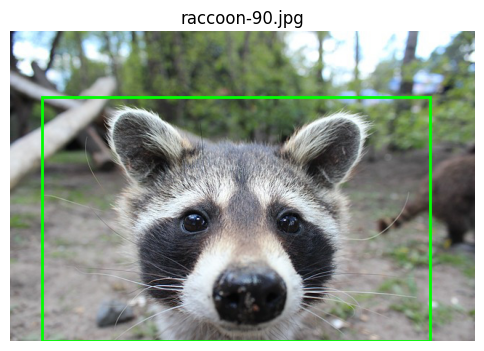

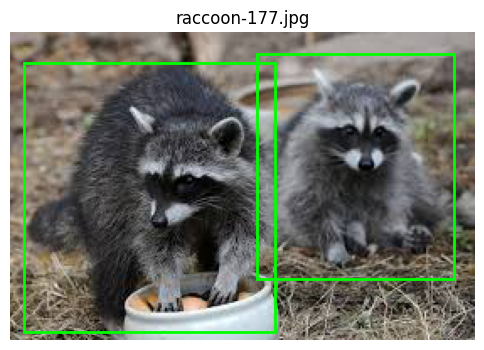

In [ ]:
def show_sample(fname):
    img_path = IMG_DIR / fname
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    boxes = df[df['filename'] == fname][['xmin','ymin','xmax','ymax']].values
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    ax = plt.gca()
    for (x1,y1,x2,y2) in boxes:
        rect = plt.Rectangle((x1,y1), x2-x1, y2-y1, fill=False, color='lime', linewidth=2)
        ax.add_patch(rect)
    plt.axis('off')
    plt.title(fname)
    plt.show()

for fname in random.sample(df['filename'].unique().tolist(), 2):
    show_sample(fname)

In [ ]:
unique_files = df['filename'].unique()
train_files, val_files = train_test_split(unique_files, test_size=0.2, random_state=42, shuffle=True)
print('train:', len(train_files), 'val:', len(val_files))

train: 128 val: 32


In [ ]:
def bbox_to_yolo(row):
    w = row['width']
    h = row['height']
    x_center = (row['xmin'] + row['xmax']) / 2.0 / w
    y_center = (row['ymin'] + row['ymax']) / 2.0 / h
    bw = (row['xmax'] - row['xmin']) / w
    bh = (row['ymax'] - row['ymin']) / h
    return x_center, y_center, bw, bh

CLASS_MAP = {'raccoon': 0}

def save_yolo_label(rows, out_path):
    lines = []
    for _, r in rows.iterrows():
        x_c, y_c, bw, bh = bbox_to_yolo(r)
        lines.append(f"{CLASS_MAP[r['class']]} {x_c:.6f} {y_c:.6f} {bw:.6f} {bh:.6f}")
    out_path.write_text('\n'.join(lines))

In [ ]:
def export_split(files, split_name, base_dir):
    img_out = base_dir / split_name / 'images'
    lbl_out = base_dir / split_name / 'labels'
    img_out.mkdir(parents=True, exist_ok=True)
    lbl_out.mkdir(parents=True, exist_ok=True)
    for fname in files:
        src_img = IMG_DIR / fname
        shutil.copy(src_img, img_out / fname)
        rows = df[df['filename'] == fname]
        save_yolo_label(rows, lbl_out / (Path(fname).stem + '.txt'))

export_split(train_files, 'train', OUTPUT_DIR)
export_split(val_files, 'val', OUTPUT_DIR)
print('Сохранено в', OUTPUT_DIR)

Сохранено в prepared_raccoon


In [ ]:
augmentations = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.4),
    A.HueSaturationValue(p=0.3),
    A.MotionBlur(blur_limit=5, p=0.2),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, border_mode=cv2.BORDER_REPLICATE, p=0.5),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

def load_yolo_labels(label_path):
    bboxes = []
    labels = []
    if not label_path.exists():
        return bboxes, labels
    for line in label_path.read_text().splitlines():
        cls, x, y, w, h = line.strip().split()
        bboxes.append([float(x), float(y), float(w), float(h)])
        labels.append(int(cls))
    return bboxes, labels

def apply_augs(split='train', n_aug=2):
    src_img_dir = OUTPUT_DIR / split / 'images'
    src_lbl_dir = OUTPUT_DIR / split / 'labels'
    dst_img_dir = AUG_DIR / split / 'images'
    dst_lbl_dir = AUG_DIR / split / 'labels'
    dst_img_dir.mkdir(parents=True, exist_ok=True)
    dst_lbl_dir.mkdir(parents=True, exist_ok=True)

    for img_path in src_img_dir.glob('*.jpg'):
        stem = img_path.stem
        lbl_path = src_lbl_dir / f"{stem}.txt"
        image = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        bboxes, labels = load_yolo_labels(lbl_path)

        cv2.imwrite(str(dst_img_dir / f"{stem}.jpg"), cv2.cvtColor(image, cv2.COLOR_RGB2BGR))
        shutil.copy(lbl_path, dst_lbl_dir / f"{stem}.txt")

        for i in range(n_aug):
            augmented = augmentations(image=image, bboxes=bboxes, class_labels=labels)
            aug_img = cv2.cvtColor(augmented['image'], cv2.COLOR_RGB2BGR)
            aug_bboxes = augmented['bboxes']
            aug_labels = augmented['class_labels']
            aug_name = f"{stem}_aug{i+1}"
            cv2.imwrite(str(dst_img_dir / f"{aug_name}.jpg"), aug_img)

            lines = []
            for cls_id, (x, y, w, h) in zip(aug_labels, aug_bboxes):
                lines.append(f"{cls_id} {x:.6f} {y:.6f} {w:.6f} {h:.6f}")
            (dst_lbl_dir / f"{aug_name}.txt").write_text('\n'.join(lines))

apply_augs('train', n_aug=2)
apply_augs('val', n_aug=1)
print('Аугментированные данные сохранены в', AUG_DIR)

/opt/homebrew/lib/python3.11/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Аугментированные данные сохранены в prepared_raccoon_aug
